<a href="https://colab.research.google.com/github/onepartho/Electrocatalysis_workshop_notebook/blob/main/adsorption_and_free_energy_diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================================================================
# 01. INSTALLATION & SETUP
# ==============================================================================
# Install required packages in Google Colab
!pip install -q ase fairchem-core gdown

import os
import json
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase import Atoms[cite: 1]
from ase.build import fcc111, add_adsorbate, molecule[cite: 1]
from ase.constraints import FixAtoms[cite: 1]
from ase.io import read[cite: 1]
from ase.optimize import BFGS[cite: 1]
from ase.visualize import view[cite: 1]
from fairchem.core import FAIRChemCalculator, pretrained_mlip[cite: 1]

# ==============================================================================
# 02. MODEL DOWNLOAD & CALCULATOR INITIALIZATION
# ==============================================================================
# Download model weights using gdown with --fuzzy support
!gdown --fuzzy 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

# Verify file integrity
if not os.path.exists("uma-s-1p1.pt") or os.path.getsize("uma-s-1p1.pt") < 100000:
    raise RuntimeError("Model download failed or returned an incomplete file.")

# Initialize the FAIRChem UMA calculator
calculator = FAIRChemCalculator(
    pretrained_mlip.load_predict_unit("uma-s-1p1.pt", device="cpu"),
    task_name="omat"
)[cite: 1]

# ==============================================================================
# 03. PLOTTING CONFIGURATION
# ==============================================================================
plt.rc("figure", figsize=(8.25/2.54, 8.25/2.54))[cite: 1]
plt.rc("figure", dpi=100)[cite: 1]
plt.rc("lines",  linewidth=4)[cite: 1]
plt.rc("font",   size=10)[cite: 1]
plt.rc("font",   family="sans-serif")[cite: 1]
plt.rc("axes",   titlesize=10)[cite: 1]
plt.rc("axes",   labelsize=9)[cite: 1]
plt.rc("xtick",  labelsize=8)[cite: 1]
plt.rc("ytick",  labelsize=8)[cite: 1]
plt.rc("legend", fontsize=8)[cite: 1]
plt.rc("figure", titlesize=10)[cite: 1]
colors = ["#1965B0", "#7BAFDE", "#90C987", "#F1932D", "#DC050C"][cite: 1]

# ==============================================================================
# 04. MOLECULAR REFERENCES (H2 and H2O)
# ==============================================================================
# Optimize H2
H2 = molecule("H2")[cite: 1]
H2.calc = calculator[cite: 1]
opt_h2 = BFGS(H2, trajectory="H2.traj", logfile="H2.log")[cite: 1]
opt_h2.run(fmax=0.01)[cite: 1]
energy_H2_ev = H2.get_potential_energy()[cite: 1]
print(f"H2 reference energy: {energy_H2_ev:.2f} eV")[cite: 1]

# Optimize H2O
H2O = molecule("H2O")[cite: 1]
H2O.calc = calculator[cite: 1]
opt_h2o = BFGS(H2O, trajectory="H2O.traj", logfile="H2O.log")[cite: 1]
opt_h2o.run(fmax=0.01)[cite: 1]
energy_H2O_ev = H2O.get_potential_energy()[cite: 1]
print(f"H2O reference energy: {energy_H2O_ev:.2f} eV")[cite: 1]

# ==============================================================================
# 05. MOLECULAR EXAMPLE: FePc and FePc*OH
# ==============================================================================
# Download FePc geometry
!wget -q https://gitlab.com/doublelayer/test-models/-/raw/main/iron-phthalocyanine-FePc-OH/FePc.xyz -O FePc.xyz[cite: 1]
FePc = read("FePc.xyz")[cite: 1]

# Fix macrocycle, relax central Fe
FePc.set_constraint(FixAtoms(indices=[atom.index for atom in FePc if atom.symbol != 'Fe']))
FePc.calc = calculator[cite: 1]
opt_fepc = BFGS(FePc, trajectory="FePc.traj", logfile="FePc.log")[cite: 1]
opt_fepc.run(fmax=0.05)[cite: 1]
energy_FePc_ev = FePc.get_potential_energy()[cite: 1]

# Construct FePc*OH
FePcOH = FePc.copy()[cite: 1]
FePcOH.set_constraint(FixAtoms(indices=[atom.index for atom in FePcOH if atom.symbol != 'Fe']))[cite: 1]
add_adsorbate(FePcOH, Atoms("OH", positions=[[0, 0, 0], [0.0, 0.6, 0.6]]), height=1.8, position=FePcOH[-1].position[:2])[cite: 1]
FePcOH.calc = calculator[cite: 1]
opt_fepcoh = BFGS(FePcOH, trajectory="FePcOH.traj", logfile="FePcOH.log")[cite: 1]
opt_fepcoh.run(fmax=0.05)[cite: 1]
energy_FePcOH_ev = FePcOH.get_potential_energy()[cite: 1]

# Compute FePc*OH adsorption free energy
energy_H2O_corrected_ev = energy_H2O_ev + 0.56 - 0.67[cite: 1]
energy_H2_corrected_ev  = energy_H2_ev  + 0.27 - 0.41[cite: 1]
free_energy_FePcOH_ev = energy_FePcOH_ev - energy_FePc_ev - (energy_H2O_corrected_ev - 0.5 * energy_H2_corrected_ev) + 0.35 - 0.50[cite: 1]
print(f"FePcOH adsorption free energy: {free_energy_FePcOH_ev:.3f} eV")[cite: 1]

# ==============================================================================
# 06. REUSABLE PT(111) WORKFLOW FUNCTIONS
# ==============================================================================
def relax_slab(metal="Pt", fmax=0.05, nx=2, ny=2, nz=3):[cite: 1]
    atoms = fcc111(metal, (nx, ny, nz), vacuum=10.0)[cite: 1]
    atoms.pbc = [True, True, True][cite: 1]
    atoms.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.index < nx * ny * (nz - 1)]))[cite: 1]
    atoms.calc = calculator[cite: 1]
    optimizer = BFGS(atoms, f"{metal}.traj", f"{metal}.log")[cite: 1]
    optimizer.run(fmax=fmax)[cite: 1]
    energy = atoms.get_potential_energy()[cite: 1]
    return atoms, energy[cite: 1]

def relax_adsorbate(slab, adsorbate, position, metal="Pt", fmax=0.05, nx=2, ny=2, nz=3):[cite: 1]
    atoms = slab.copy()[cite: 1]
    if adsorbate == "O":[cite: 1]
        ads = Atoms("O", positions=[(0, 0, 0)])[cite: 1]
        height = 1.5[cite: 1]
    elif adsorbate == "OH":[cite: 1]
        ads = Atoms("OH", positions=[(0, 0, 0), (0.7, 0, 0.7)])[cite: 1]
        height = 1.8[cite: 1]
    elif adsorbate == "OOH":[cite: 1]
        ads = Atoms("OOH", positions=[(0, 0, 0), (0.1, 0, 1.5), (0.7, 0, 2.2)])[cite: 1]
        height = 1.8[cite: 1]
    add_adsorbate(atoms, ads, height, position)[cite: 1]
    atoms.pbc = [True, True, True][cite: 1]
    atoms.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.index < nx * ny * (nz - 1)]))[cite: 1]
    atoms.calc = calculator[cite: 1]
    optimizer = BFGS(atoms, f"{metal}{adsorbate}.traj", f"{metal}{adsorbate}.log")[cite: 1]
    optimizer.run(fmax=fmax)[cite: 1]
    energy = atoms.get_potential_energy()[cite: 1]
    return atoms, energy[cite: 1]

def adsorption_energies(energy_Pt111_ev, energy_O_Pt111_ev, energy_OH_Pt111_ev, energy_OOH_Pt111_ev, energy_H2O_ev, energy_H2_ev):[cite: 1]
    e_H2O = energy_H2O_ev + 0.56 - 0.67
    e_H2 = energy_H2_ev + 0.27 - 0.41
    free_energy_O_ev = energy_O_Pt111_ev - energy_Pt111_ev - (e_H2O - e_H2) + 0.05 - 0[cite: 1]
    free_energy_OH_ev = energy_OH_Pt111_ev - energy_Pt111_ev - (e_H2O - 0.5 * e_H2) + 0.35 - 0.50[cite: 1]
    free_energy_OOH_ev = energy_OOH_Pt111_ev - energy_Pt111_ev - (2 * e_H2O - 1.5 * e_H2) + 0.40 - 0.30[cite: 1]
    return free_energy_O_ev, free_energy_OH_ev, free_energy_OOH_ev[cite: 1]

# ==============================================================================
# 07. PT(111) ADSORPTION CALCULATIONS
# ==============================================================================
Pt111, energy_Pt111_ev = relax_slab()[cite: 1]
O_Pt111, energy_O_Pt111_ev = relax_adsorbate(Pt111, "O", position="ontop")[cite: 1]
OH_Pt111, energy_OH_Pt111_ev = relax_adsorbate(Pt111, "OH", position="ontop")[cite: 1]
OOH_Pt111, energy_OOH_Pt111_ev = relax_adsorbate(Pt111, "OOH", position="ontop")[cite: 1]

free_energy_O_ev, free_energy_OH_ev, free_energy_OOH_ev = adsorption_energies(
    energy_Pt111_ev, energy_O_Pt111_ev, energy_OH_Pt111_ev, energy_OOH_Pt111_ev, energy_H2O_ev, energy_H2_ev
)[cite: 1]

print(f"G_OOH = {free_energy_OOH_ev:.3f} eV")[cite: 1]
print(f"G_O   = {free_energy_O_ev:.3f} eV")[cite: 1]
print(f"G_OH  = {free_energy_OH_ev:.3f} eV")[cite: 1]

# ==============================================================================
# 08. THERMODYNAMIC STEP ANALYSIS & DIAGRAM FUNCTIONS
# ==============================================================================
def limiting_potential(intermediate_energies_ev):[cite: 1]
    G_OOH, G_O, G_OH = intermediate_energies_ev[cite: 1]
    step_energies_ev = np.array([4.92 - G_OOH, G_OOH - G_O, G_O - G_OH, G_OH])[cite: 1]
    limiting_step = int(np.argmin(step_energies_ev))[cite: 1]
    limiting_potential_v = float(step_energies_ev[limiting_step])[cite: 1]
    overpotential_v = 1.23 - limiting_potential_v[cite: 1]
    return step_energies_ev, limiting_step, limiting_potential_v, overpotential_v[cite: 1]

def plot_at_potential(potential_v, intermediate_energies_ev, color="#0000cc", metal="Pt", peroxide=False):[cite: 1]
    states = [
        4.92 - 4 * potential_v,
        intermediate_energies_ev[0] - 3 * potential_v,
        intermediate_energies_ev[1] - 2 * potential_v,
        intermediate_energies_ev[2] - potential_v,
        0
    ][cite: 1]
    if peroxide:[cite: 1]
        plt.plot([1.2, 1.8], [states[1], 4.92 - 1.36 - 2 * potential_v], color="#DC050C", linestyle=":", linewidth=1, zorder=10)[cite: 1]
        plt.plot([1.8, 2.2], [4.92 - 1.36 - 2 * potential_v, 4.92 - 1.36 - 2 * potential_v], color="#DC050C", linewidth=3, zorder=10)[cite: 1]
    plt.plot([-0.2, 0.2], [states[0], states[0]], color=color, linewidth=3, label=f"{metal}, $U$={potential_v} V")[cite: 1]
    plt.plot([0.8, 1.2], [states[1], states[1]], color=color, linewidth=3)[cite: 1]
    plt.plot([1.8, 2.2], [states[2], states[2]], color=color, linewidth=3)[cite: 1]
    plt.plot([2.8, 3.2], [states[3], states[3]], color=color, linewidth=3)[cite: 1]
    plt.plot([3.8, 4.2], [states[4], states[4]], color=color, linewidth=3)[cite: 1]
    plt.plot([0.2, 0.8], [states[0], states[1]], color=color, linestyle=":", linewidth=1)[cite: 1]
    plt.plot([1.2, 1.8], [states[1], states[2]], color=color, linestyle=":", linewidth=1)[cite: 1]
    plt.plot([2.2, 2.8], [states[2], states[3]], color=color, linestyle=":", linewidth=1)[cite: 1]
    plt.plot([3.2, 3.8], [states[3], states[4]], color=color, linestyle=":", linewidth=1)[cite: 1]

# Plot Pt(111) Free-Energy Diagram
intermediate_energies_ev = [free_energy_OOH_ev, free_energy_O_ev, free_energy_OH_ev][cite: 1]
step_names = ["O2 to OOH*", "OOH* to O*", "O* to OH*", "OH* to H2O"][cite: 1]
step_energies_ev, limiting_step, limiting_potential_v, overpotential_v = limiting_potential(intermediate_energies_ev)[cite: 1]

for name, energy_ev in zip(step_names, step_energies_ev):[cite: 1]
    print(f"{name}: {energy_ev:.2f} eV")[cite: 1]
print(f"Limiting step: {step_names[limiting_step]}")[cite: 1]
print(f"U_L = {limiting_potential_v:.2f} V")[cite: 1]
print(f"eta = {overpotential_v:.2f} V")[cite: 1]

plt.figure()[cite: 1]
plot_at_potential(1.23, intermediate_energies_ev, colors[1], "Pt(111)")[cite: 1]
plot_at_potential(round(limiting_potential_v, 2), intermediate_energies_ev, colors[2], "Pt(111)")[cite: 1]
plot_at_potential(0.0, intermediate_energies_ev, colors[0], "Pt(111)")[cite: 1]
plt.title(f"$\\eta$ (Pt(111)) = {overpotential_v:.2f} V")[cite: 1]
plt.xlabel("Reaction coordinate")[cite: 1]
plt.ylabel("Free energies / eV")[cite: 1]
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])[cite: 1]
plt.legend()[cite: 1]
plt.show()[cite: 1]

# ==============================================================================
# 09. ZENODO DATABASE PROCESSING & BENCHMARKING
# ==============================================================================
zenodo_base_url = "https://zenodo.org/records/19023993/files"[cite: 1]
database_files = ["molecules.json", "slab_database.json", "adsorbate_database.json"][cite: 1]

for filename in database_files:[cite: 1]
    database_path = Path(filename)[cite: 1]
    if not database_path.exists():[cite: 1]
        urlretrieve(f"{zenodo_base_url}/{filename}?download=1", database_path)[cite: 1]

def load_json_records(filename):[cite: 1]
    path = Path(filename)[cite: 1]
    try:
        text = path.read_text(encoding="utf-16")[cite: 1]
    except UnicodeDecodeError:
        text = path.read_text(encoding="utf-8")

    decoder = json.JSONDecoder()[cite: 1]
    records = [][cite: 1]
    position = 0[cite: 1]
    while position < len(text):[cite: 1]
        while position < len(text) and text[position].isspace():[cite: 1]
            position += 1[cite: 1]
        if position >= len(text):[cite: 1]
            break[cite: 1]
        document, position = decoder.raw_decode(text, position)[cite: 1]
        for key, value in document.items():[cite: 1]
            if key.isdigit():[cite: 1]
                records.append(value)[cite: 1]
    return records[cite: 1]

def records_for_functional(records):[cite: 1]
    selected_records = [][cite: 1]
    for row in records:[cite: 1]
        key_value_pairs = row.get("key_value_pairs", {})[cite: 1]
        if key_value_pairs.get("xc") == functional and row.get("energy") is not None:[cite: 1]
            selected_records.append(row)[cite: 1]
    return selected_records[cite: 1]

functional = "BEEF-vdW"[cite: 1]
molecule_records = load_json_records("molecules.json")[cite: 1]
slab_records_json = load_json_records("slab_database.json")[cite: 1]
adsorbate_records_json = load_json_records("adsorbate_database.json")[cite: 1]
molecules = records_for_functional(molecule_records)[cite: 1]

for row in molecules:[cite: 1]
    if row["key_value_pairs"].get("smiles") == "O":[cite: 1]
        db_energy_H2O_ev = row["energy"]
        break[cite: 1]
for row in molecules:[cite: 1]
    if row["key_value_pairs"].get("smiles") == "[HH]":[cite: 1]
        db_energy_H2_ev = row["energy"]
        break[cite: 1]

db_energy_H2O_ev = db_energy_H2O_ev + 0.56 - 0.67
db_energy_H2_ev = db_energy_H2_ev + 0.27 - 0.41

slab_records = [][cite: 1]
for row in records_for_functional(slab_records_json):[cite: 1]
    structure_string = row.get("key_value_pairs", {}).get("structure_str")[cite: 1]
    if structure_string:[cite: 1]
        metal = structure_string.split("_")[0][cite: 1]
        record = {"metal": metal, "energy_Pt111_ev": row["energy"]}[cite: 1]
        slab_records.append(record)[cite: 1]
slab_table = pd.DataFrame(slab_records)[cite: 1]
slab_table = slab_table.drop_duplicates("metal")[cite: 1]
slab_energies = slab_table.set_index("metal")[cite: 1]

adsorbate_records = [][cite: 1]
for row in records_for_functional(adsorbate_records_json):[cite: 1]
    structure_string = row.get("key_value_pairs", {}).get("structure_str")[cite: 1]
    if not structure_string:[cite: 1]
        continue[cite: 1]
    metal, unused, adsorbate, position = structure_string.split("_")[cite: 1]
    if position == "top" and adsorbate in {"O", "OH", "OOH"}:[cite: 1]
        record = {"metal": metal, "adsorbate": adsorbate, "energy_adsorbate_ev": row["energy"]}[cite: 1]
        adsorbate_records.append(record)[cite: 1]
adsorbate_table = pd.DataFrame(adsorbate_records)[cite: 1]
adsorbate_table = adsorbate_table.drop_duplicates(["metal", "adsorbate"])[cite: 1]
adsorbate_energies = adsorbate_table.pivot(index="metal", columns="adsorbate", values="energy_adsorbate_ev")[cite: 1]

metal_energies = slab_energies.join(adsorbate_energies, how="inner")[cite: 1]
metal_energies = metal_energies.dropna(subset=["O", "OH", "OOH"])[cite: 1]
metal_energies["G_O"] = metal_energies["O"] - metal_energies["energy_Pt111_ev"] - (db_energy_H2O_ev - db_energy_H2_ev) + 0.05 - 0
metal_energies["G_OH"] = metal_energies["OH"] - metal_energies["energy_Pt111_ev"] - (db_energy_H2O_ev - 0.5 * db_energy_H2_ev) + 0.35 - 0.50
metal_energies["G_OOH"] = metal_energies["OOH"] - metal_energies["energy_Pt111_ev"] - (2 * db_energy_H2O_ev - 1.5 * db_energy_H2_ev) + 0.40 - 0.30
comparison_energies = metal_energies[["G_OOH", "G_O", "G_OH"]].copy()[cite: 1]
comparison_energies.loc["FePc"] = {"G_OOH": 4.20, "G_O": 1.91, "G_OH": 0.95}[cite: 1]
comparison_energies = comparison_energies.sort_index()[cite: 1]
print(comparison_energies)

# ==============================================================================
# 10. FEPC BENCHMARK DIAGRAM
# ==============================================================================
metal = "FePc"[cite: 1]
metal_row = comparison_energies.loc[metal][cite: 1]
fepc_intermediate_energies_ev = [metal_row.G_OOH, metal_row.G_O, metal_row.G_OH][cite: 1]
step_energies_ev, limiting_step, limiting_potential_v, overpotential_v = limiting_potential(fepc_intermediate_energies_ev)[cite: 1]

print(f"\nCatalyst: {metal}")[cite: 1]
print(f"G_OOH = {fepc_intermediate_energies_ev[0]:.2f} eV")[cite: 1]
print(f"G_O   = {fepc_intermediate_energies_ev[1]:.2f} eV")[cite: 1]
print(f"G_OH  = {fepc_intermediate_energies_ev[2]:.2f} eV")[cite: 1]
print(f"Limiting step: {step_names[limiting_step]}")[cite: 1]
print(f"U_L = {limiting_potential_v:.2f} V")[cite: 1]
print(f"eta = {overpotential_v:.2f} V")[cite: 1]

plt.figure()[cite: 1]
plot_at_potential(1.23, fepc_intermediate_energies_ev, colors[1], metal)[cite: 1]
plot_at_potential(round(limiting_potential_v, 2), fepc_intermediate_energies_ev, colors[2], metal)[cite: 1]
plot_at_potential(0.0, fepc_intermediate_energies_ev, colors[0], metal)[cite: 1]
plt.xlabel("Reaction coordinate")[cite: 1]
plt.ylabel("Free energies / eV")[cite: 1]
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])[cite: 1]
plt.legend()[cite: 1]
plt.show()[cite: 1]

SyntaxError: invalid syntax (1650643793.py, line 15)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 38.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.3/572.3 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 450.7/450.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.1/304.1 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.6/62.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 75.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.3/78.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/2

W0913 18:05:10.875000 1633 torch/_logging/_internal.py:1345] [0/0] Profiler record function <class 'torch.autograd.profiler.record_function'> will be ignored
/usr/local/lib/python3.13/dist-packages/torch/_inductor/lowering.py:2352: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(
Use inference_settings='batch' for heterogeneous batched evaluations.


H2 reference energy: -6.64 eV


H2O reference energy: -13.93 eV
FePcOH adsorption free energy: 2.806 eV
G_OOH = 3.726 eV
G_O   = 2.632 eV
G_OH  = 0.668 eV
O2 to OOH*: 1.19 eV
OOH* to O*: 1.09 eV
O* to OH*: 1.96 eV
OH* to H2O: 0.67 eV
Limiting step: OH* to H2O
U_L = 0.67 V
eta = 0.56 V


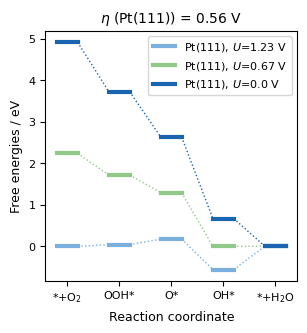

          G_OOH       G_O      G_OH
metal                              
Ag     4.237804  3.325199  0.989241
Au     4.622869  3.865709  1.425194
Cu     3.846751  2.577003  0.568179
FePc   4.200000  1.910000  0.950000
Ir     3.590423  1.609312  0.403276
Pd     3.971615  2.860590  0.860581
Pt     3.973696  2.776338  0.833430
Rh     3.564487  1.847798  0.432013

Catalyst: FePc
G_OOH = 4.20 eV
G_O   = 1.91 eV
G_OH  = 0.95 eV
Limiting step: O2 to OOH*
U_L = 0.72 V
eta = 0.51 V


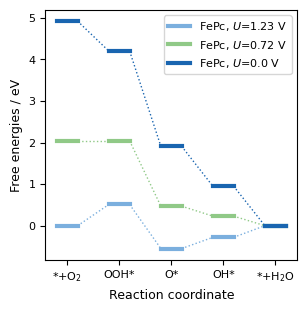

In [2]:
# ==============================================================================
# 01. INSTALLATION & SETUP
# ==============================================================================
# Install required packages in Google Colab
!pip install -q ase fairchem-core gdown

import os
import json
from pathlib import Path
from urllib.request import urlretrieve
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase import Atoms
from ase.build import fcc111, add_adsorbate, molecule
from ase.constraints import FixAtoms
from ase.io import read
from ase.optimize import BFGS
from ase.visualize import view
from fairchem.core import FAIRChemCalculator, pretrained_mlip

# ==============================================================================
# 02. MODEL DOWNLOAD & CALCULATOR INITIALIZATION
# ==============================================================================
# Download model weights using gdown with --fuzzy support
!gdown --fuzzy 1pw3jkPMWL6CLmpRGhBPdvzoLn4MzpTEX -O uma-s-1p1.pt

# Verify file integrity
if not os.path.exists("uma-s-1p1.pt") or os.path.getsize("uma-s-1p1.pt") < 100000:
    raise RuntimeError("Model download failed or returned an incomplete file.")

# Initialize the FAIRChem UMA calculator
calculator = FAIRChemCalculator(
    pretrained_mlip.load_predict_unit("uma-s-1p1.pt", device="cpu"),
    task_name="omat"
)

# ==============================================================================
# 03. PLOTTING CONFIGURATION
# ==============================================================================
plt.rc("figure", figsize=(8.25/2.54, 8.25/2.54))
plt.rc("figure", dpi=100)
plt.rc("lines",  linewidth=4)
plt.rc("font",   size=10)
plt.rc("font",   family="sans-serif")
plt.rc("axes",   titlesize=10)
plt.rc("axes",   labelsize=9)
plt.rc("xtick",  labelsize=8)
plt.rc("ytick",  labelsize=8)
plt.rc("legend", fontsize=8)
plt.rc("figure", titlesize=10)
colors = ["#1965B0", "#7BAFDE", "#90C987", "#F1932D", "#DC050C"]

# ==============================================================================
# 04. MOLECULAR REFERENCES (H2 and H2O)
# ==============================================================================
# Optimize H2
H2 = molecule("H2")
H2.calc = calculator
opt_h2 = BFGS(H2, trajectory="H2.traj", logfile="H2.log")
opt_h2.run(fmax=0.01)
energy_H2_ev = H2.get_potential_energy()
print(f"H2 reference energy: {energy_H2_ev:.2f} eV")

# Optimize H2O
H2O = molecule("H2O")
H2O.calc = calculator
opt_h2o = BFGS(H2O, trajectory="H2O.traj", logfile="H2O.log")
opt_h2o.run(fmax=0.01)
energy_H2O_ev = H2O.get_potential_energy()
print(f"H2O reference energy: {energy_H2O_ev:.2f} eV")

# ==============================================================================
# 05. MOLECULAR EXAMPLE: FePc and FePc*OH
# ==============================================================================
# Download FePc geometry
!wget -q https://gitlab.com/doublelayer/test-models/-/raw/main/iron-phthalocyanine-FePc-OH/FePc.xyz -O FePc.xyz
FePc = read("FePc.xyz")

# Fix macrocycle, relax central Fe
FePc.set_constraint(FixAtoms(indices=[atom.index for atom in FePc if atom.symbol != 'Fe']))
FePc.calc = calculator
opt_fepc = BFGS(FePc, trajectory="FePc.traj", logfile="FePc.log")
opt_fepc.run(fmax=0.05)
energy_FePc_ev = FePc.get_potential_energy()

# Construct FePc*OH
FePcOH = FePc.copy()
FePcOH.set_constraint(FixAtoms(indices=[atom.index for atom in FePcOH if atom.symbol != 'Fe']))
add_adsorbate(FePcOH, Atoms("OH", positions=[[0, 0, 0], [0.0, 0.6, 0.6]]), height=1.8, position=FePcOH[-1].position[:2])
FePcOH.calc = calculator
opt_fepcoh = BFGS(FePcOH, trajectory="FePcOH.traj", logfile="FePcOH.log")
opt_fepcoh.run(fmax=0.05)
energy_FePcOH_ev = FePcOH.get_potential_energy()

# Compute FePc*OH adsorption free energy
energy_H2O_corrected_ev = energy_H2O_ev + 0.56 - 0.67
energy_H2_corrected_ev  = energy_H2_ev  + 0.27 - 0.41
free_energy_FePcOH_ev = energy_FePcOH_ev - energy_FePc_ev - (energy_H2O_corrected_ev - 0.5 * energy_H2_corrected_ev) + 0.35 - 0.50
print(f"FePcOH adsorption free energy: {free_energy_FePcOH_ev:.3f} eV")

# ==============================================================================
# 06. REUSABLE PT(111) WORKFLOW FUNCTIONS
# ==============================================================================
def relax_slab(metal="Pt", fmax=0.05, nx=2, ny=2, nz=3):
    atoms = fcc111(metal, (nx, ny, nz), vacuum=10.0)
    atoms.pbc = [True, True, True]
    atoms.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.index < nx * ny * (nz - 1)]))
    atoms.calc = calculator
    optimizer = BFGS(atoms, f"{metal}.traj", f"{metal}.log")
    optimizer.run(fmax=fmax)
    energy = atoms.get_potential_energy()
    return atoms, energy

def relax_adsorbate(slab, adsorbate, position, metal="Pt", fmax=0.05, nx=2, ny=2, nz=3):
    atoms = slab.copy()
    if adsorbate == "O":
        ads = Atoms("O", positions=[(0, 0, 0)])
        height = 1.5
    elif adsorbate == "OH":
        ads = Atoms("OH", positions=[(0, 0, 0), (0.7, 0, 0.7)])
        height = 1.8
    elif adsorbate == "OOH":
        ads = Atoms("OOH", positions=[(0, 0, 0), (0.1, 0, 1.5), (0.7, 0, 2.2)])
        height = 1.8
    add_adsorbate(atoms, ads, height, position)
    atoms.pbc = [True, True, True]
    atoms.set_constraint(FixAtoms(indices=[atom.index for atom in atoms if atom.index < nx * ny * (nz - 1)]))
    atoms.calc = calculator
    optimizer = BFGS(atoms, f"{metal}{adsorbate}.traj", f"{metal}{adsorbate}.log")
    optimizer.run(fmax=fmax)
    energy = atoms.get_potential_energy()
    return atoms, energy

def adsorption_energies(energy_Pt111_ev, energy_O_Pt111_ev, energy_OH_Pt111_ev, energy_OOH_Pt111_ev, energy_H2O_ev, energy_H2_ev):
    e_H2O = energy_H2O_ev + 0.56 - 0.67
    e_H2 = energy_H2_ev + 0.27 - 0.41
    free_energy_O_ev = energy_O_Pt111_ev - energy_Pt111_ev - (e_H2O - e_H2) + 0.05 - 0
    free_energy_OH_ev = energy_OH_Pt111_ev - energy_Pt111_ev - (e_H2O - 0.5 * e_H2) + 0.35 - 0.50
    free_energy_OOH_ev = energy_OOH_Pt111_ev - energy_Pt111_ev - (2 * e_H2O - 1.5 * e_H2) + 0.40 - 0.30
    return free_energy_O_ev, free_energy_OH_ev, free_energy_OOH_ev

# ==============================================================================
# 07. PT(111) ADSORPTION CALCULATIONS
# ==============================================================================
Pt111, energy_Pt111_ev = relax_slab()
O_Pt111, energy_O_Pt111_ev = relax_adsorbate(Pt111, "O", position="ontop")
OH_Pt111, energy_OH_Pt111_ev = relax_adsorbate(Pt111, "OH", position="ontop")
OOH_Pt111, energy_OOH_Pt111_ev = relax_adsorbate(Pt111, "OOH", position="ontop")

free_energy_O_ev, free_energy_OH_ev, free_energy_OOH_ev = adsorption_energies(
    energy_Pt111_ev, energy_O_Pt111_ev, energy_OH_Pt111_ev, energy_OOH_Pt111_ev, energy_H2O_ev, energy_H2_ev
)

print(f"G_OOH = {free_energy_OOH_ev:.3f} eV")
print(f"G_O   = {free_energy_O_ev:.3f} eV")
print(f"G_OH  = {free_energy_OH_ev:.3f} eV")

# ==============================================================================
# 08. THERMODYNAMIC STEP ANALYSIS & DIAGRAM FUNCTIONS
# ==============================================================================
def limiting_potential(intermediate_energies_ev):
    G_OOH, G_O, G_OH = intermediate_energies_ev
    step_energies_ev = np.array([4.92 - G_OOH, G_OOH - G_O, G_O - G_OH, G_OH])
    limiting_step = int(np.argmin(step_energies_ev))
    limiting_potential_v = float(step_energies_ev[limiting_step])
    overpotential_v = 1.23 - limiting_potential_v
    return step_energies_ev, limiting_step, limiting_potential_v, overpotential_v

def plot_at_potential(potential_v, intermediate_energies_ev, color="#0000cc", metal="Pt", peroxide=False):
    states = [
        4.92 - 4 * potential_v,
        intermediate_energies_ev[0] - 3 * potential_v,
        intermediate_energies_ev[1] - 2 * potential_v,
        intermediate_energies_ev[2] - potential_v,
        0
    ]
    if peroxide:
        plt.plot([1.2, 1.8], [states[1], 4.92 - 1.36 - 2 * potential_v], color="#DC050C", linestyle=":", linewidth=1, zorder=10)
        plt.plot([1.8, 2.2], [4.92 - 1.36 - 2 * potential_v, 4.92 - 1.36 - 2 * potential_v], color="#DC050C", linewidth=3, zorder=10)
    plt.plot([-0.2, 0.2], [states[0], states[0]], color=color, linewidth=3, label=f"{metal}, $U$={potential_v} V")
    plt.plot([0.8, 1.2], [states[1], states[1]], color=color, linewidth=3)
    plt.plot([1.8, 2.2], [states[2], states[2]], color=color, linewidth=3)
    plt.plot([2.8, 3.2], [states[3], states[3]], color=color, linewidth=3)
    plt.plot([3.8, 4.2], [states[4], states[4]], color=color, linewidth=3)
    plt.plot([0.2, 0.8], [states[0], states[1]], color=color, linestyle=":", linewidth=1)
    plt.plot([1.2, 1.8], [states[1], states[2]], color=color, linestyle=":", linewidth=1)
    plt.plot([2.2, 2.8], [states[2], states[3]], color=color, linestyle=":", linewidth=1)
    plt.plot([3.2, 3.8], [states[3], states[4]], color=color, linestyle=":", linewidth=1)

# Plot Pt(111) Free-Energy Diagram
intermediate_energies_ev = [free_energy_OOH_ev, free_energy_O_ev, free_energy_OH_ev]
step_names = ["O2 to OOH*", "OOH* to O*", "O* to OH*", "OH* to H2O"]
step_energies_ev, limiting_step, limiting_potential_v, overpotential_v = limiting_potential(intermediate_energies_ev)

for name, energy_ev in zip(step_names, step_energies_ev):
    print(f"{name}: {energy_ev:.2f} eV")
print(f"Limiting step: {step_names[limiting_step]}")
print(f"U_L = {limiting_potential_v:.2f} V")
print(f"eta = {overpotential_v:.2f} V")

plt.figure()
plot_at_potential(1.23, intermediate_energies_ev, colors[1], "Pt(111)")
plot_at_potential(round(limiting_potential_v, 2), intermediate_energies_ev, colors[2], "Pt(111)")
plot_at_potential(0.0, intermediate_energies_ev, colors[0], "Pt(111)")
plt.title(f"$\\eta$ (Pt(111)) = {overpotential_v:.2f} V")
plt.xlabel("Reaction coordinate")
plt.ylabel("Free energies / eV")
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])
plt.legend()
plt.show()

# ==============================================================================
# 09. ZENODO DATABASE PROCESSING & BENCHMARKING
# ==============================================================================
zenodo_base_url = "https://zenodo.org/records/19023993/files"
database_files = ["molecules.json", "slab_database.json", "adsorbate_database.json"]

for filename in database_files:
    database_path = Path(filename)
    if not database_path.exists():
        urlretrieve(f"{zenodo_base_url}/{filename}?download=1", database_path)

def load_json_records(filename):
    path = Path(filename)
    try:
        text = path.read_text(encoding="utf-16")
    except UnicodeDecodeError:
        text = path.read_text(encoding="utf-8")

    decoder = json.JSONDecoder()
    records = []
    position = 0
    while position < len(text):
        while position < len(text) and text[position].isspace():
            position += 1
        if position >= len(text):
            break
        document, position = decoder.raw_decode(text, position)
        for key, value in document.items():
            if key.isdigit():
                records.append(value)
    return records

def records_for_functional(records):
    selected_records = []
    for row in records:
        key_value_pairs = row.get("key_value_pairs", {})
        if key_value_pairs.get("xc") == functional and row.get("energy") is not None:
            selected_records.append(row)
    return selected_records

functional = "BEEF-vdW"
molecule_records = load_json_records("molecules.json")
slab_records_json = load_json_records("slab_database.json")
adsorbate_records_json = load_json_records("adsorbate_database.json")
molecules = records_for_functional(molecule_records)

for row in molecules:
    if row["key_value_pairs"].get("smiles") == "O":
        db_energy_H2O_ev = row["energy"]
        break
for row in molecules:
    if row["key_value_pairs"].get("smiles") == "[HH]":
        db_energy_H2_ev = row["energy"]
        break

db_energy_H2O_ev = db_energy_H2O_ev + 0.56 - 0.67
db_energy_H2_ev = db_energy_H2_ev + 0.27 - 0.41

slab_records = []
for row in records_for_functional(slab_records_json):
    structure_string = row.get("key_value_pairs", {}).get("structure_str")
    if structure_string:
        metal = structure_string.split("_")[0]
        record = {"metal": metal, "energy_Pt111_ev": row["energy"]}
        slab_records.append(record)
slab_table = pd.DataFrame(slab_records)
slab_table = slab_table.drop_duplicates("metal")
slab_energies = slab_table.set_index("metal")

adsorbate_records = []
for row in records_for_functional(adsorbate_records_json):
    structure_string = row.get("key_value_pairs", {}).get("structure_str")
    if not structure_string:
        continue
    metal, unused, adsorbate, position = structure_string.split("_")
    if position == "top" and adsorbate in {"O", "OH", "OOH"}:
        record = {"metal": metal, "adsorbate": adsorbate, "energy_adsorbate_ev": row["energy"]}
        adsorbate_records.append(record)
adsorbate_table = pd.DataFrame(adsorbate_records)
adsorbate_table = adsorbate_table.drop_duplicates(["metal", "adsorbate"])
adsorbate_energies = adsorbate_table.pivot(index="metal", columns="adsorbate", values="energy_adsorbate_ev")

metal_energies = slab_energies.join(adsorbate_energies, how="inner")
metal_energies = metal_energies.dropna(subset=["O", "OH", "OOH"])
metal_energies["G_O"] = metal_energies["O"] - metal_energies["energy_Pt111_ev"] - (db_energy_H2O_ev - db_energy_H2_ev) + 0.05 - 0
metal_energies["G_OH"] = metal_energies["OH"] - metal_energies["energy_Pt111_ev"] - (db_energy_H2O_ev - 0.5 * db_energy_H2_ev) + 0.35 - 0.50
metal_energies["G_OOH"] = metal_energies["OOH"] - metal_energies["energy_Pt111_ev"] - (2 * db_energy_H2O_ev - 1.5 * db_energy_H2_ev) + 0.40 - 0.30
comparison_energies = metal_energies[["G_OOH", "G_O", "G_OH"]].copy()
comparison_energies.loc["FePc"] = {"G_OOH": 4.20, "G_O": 1.91, "G_OH": 0.95}
comparison_energies = comparison_energies.sort_index()
print(comparison_energies)

# ==============================================================================
# 10. FEPC BENCHMARK DIAGRAM
# ==============================================================================
metal = "FePc"
metal_row = comparison_energies.loc[metal]
fepc_intermediate_energies_ev = [metal_row.G_OOH, metal_row.G_O, metal_row.G_OH]
step_energies_ev, limiting_step, limiting_potential_v, overpotential_v = limiting_potential(fepc_intermediate_energies_ev)

print(f"\nCatalyst: {metal}")
print(f"G_OOH = {fepc_intermediate_energies_ev[0]:.2f} eV")
print(f"G_O   = {fepc_intermediate_energies_ev[1]:.2f} eV")
print(f"G_OH  = {fepc_intermediate_energies_ev[2]:.2f} eV")
print(f"Limiting step: {step_names[limiting_step]}")
print(f"U_L = {limiting_potential_v:.2f} V")
print(f"eta = {overpotential_v:.2f} V")

plt.figure()
plot_at_potential(1.23, fepc_intermediate_energies_ev, colors[1], metal)
plot_at_potential(round(limiting_potential_v, 2), fepc_intermediate_energies_ev, colors[2], metal)
plot_at_potential(0.0, fepc_intermediate_energies_ev, colors[0], metal)
plt.xlabel("Reaction coordinate")
plt.ylabel("Free energies / eV")
plt.xticks([0, 1, 2, 3, 4], ["*+O$_2$", "OOH*", "O*", "OH*", "*+H$_2$O"])
plt.legend()
plt.show()


# New Section